In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from few.waveform import GenerateEMRIWaveform, FastSchwarzschildEccentricFlux, FastKerrEccentricEquatorialFlux


import os
import sys

# Change to the desired directory
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

# Add it to Python path
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglike
import modeselector
import dynesty
# import gc
# import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

import stableemrifisher
stableemrifisher.__file__
from tqdm import tqdm
from stableemrifisher.fisher.fisher import StableEMRIFisher

# GPU configuration
use_gpu = True
dt = 10     # Time step
T = 0.25   # Total time

# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
        "err": 1e-15  # Error tolerance 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": "cuda12x" # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": "cuda12x",  # Force GPU
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs = {
    "force_backend": "cuda12x",  # Force GPU
    "pad_output": True
}

waveform_class = FastKerrEccentricEquatorialFlux
waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
                             amplitude_kwargs=amplitude_kwargs,
                             Ylm_kwargs=Ylm_kwargs,
                             sum_kwargs=sum_kwargs,
                             use_gpu=use_gpu)

 
#waveform generator setup
waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(frame='detector')

waveform_gen = GenerateEMRIWaveform(
    waveform_class, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs,
    use_gpu=use_gpu
)

gwf = GWfuncs.GravWaveAnalysis(T, dt)

from lisatools.sensitivity import get_sensitivity, CornishLISASens

sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                      stats_for_nerds = True, use_gpu = use_gpu,
                      deriv_type='stable', noise_model=get_sensitivity, noise_kwargs={'sens_fn':CornishLISASens, 'return_type': 'PSD'}, channels=["A"])


startup


In [ ]:
# Source parameters
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 7.5
e0 = 0.4 
xI0 = 1.0
dist = 0.5 # Gpc
# Polar and azimuthal angles .. detector frame
# S = Solar system barycenter
# K = spin angular momentum of the MBH
qS = 0.5 
phiS = 1 # FIXED. NOTE: might need to change later? make sure no same angles ?
qK = 1 #fixed
phiK = phiS + np.pi/3
# Phases
Phi_phi0 = 0.4
Phi_theta0 = 0.0 # equatorial
Phi_r0 = 0.5


In [3]:
waveform = waveform_gen(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,  T=T, dt=dt)

In [4]:
hf = gwf.freq_wave(waveform)
np.sqrt(gwf.inner(hf,hf))

array(107.43946161)

T:  0.25 dt:  10
Body is not plunging, Fisher should be stable.
wave ndim: 2
Computing SNR for parameters: (1000000.0, 30.0, 0.7, 7.5, 0.4, 1.0, 0.5, 0.5, 1, 1, 2.0471975511965974, 0.4, 0.0, 0.5)
Waveform Generated. SNR: 107.4394616101364
calculating stable deltas...
Gamma_ii for m1: 592.8246153666494
Gamma_ii for m1: 592.8246153555673
Gamma_ii for m1: 592.8246153541139
Gamma_ii for m1: 592.8246154215007
Gamma_ii for m1: 592.8246154226514
Gamma_ii for m1: 592.8246132316539
Gamma_ii for m1: 592.8245937948226
Gamma_ii for m1: 592.8246920518216
[1.8693689444083802e-11, 2.451606252154343e-12, 1.1367061089931033e-10, 1.9411106446681274e-12, 3.695861257105813e-09, 3.278681668055054e-08, 1.6574376925376608e-07]
3


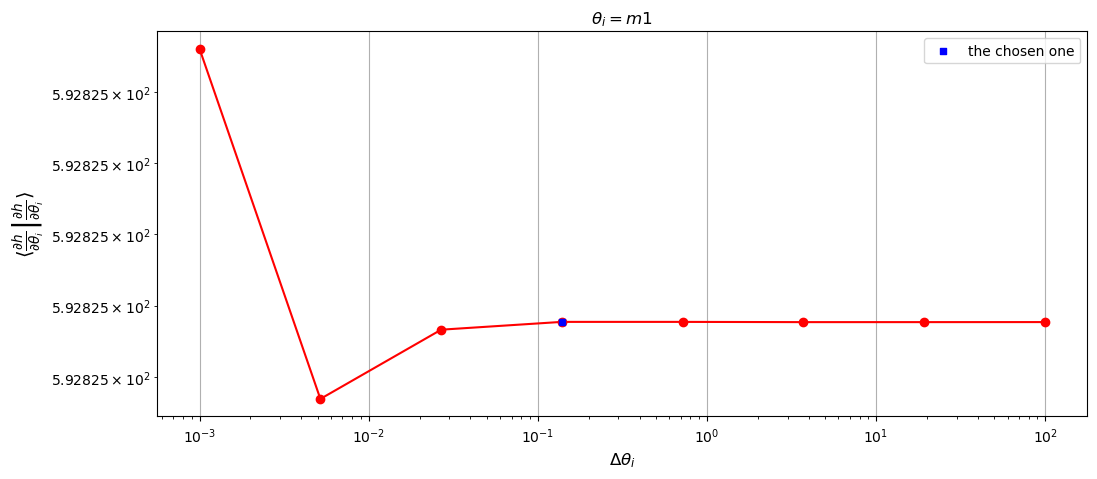

Gamma_ii for m2: 21227273818.435528
Gamma_ii for m2: 21227273818.43465
Gamma_ii for m2: 21227273813.319714
Gamma_ii for m2: 21227273766.620632
Gamma_ii for m2: 21227273899.844357
Gamma_ii for m2: 21227273384.163345
Gamma_ii for m2: 21227266988.09415
Gamma_ii for m2: 21227260563.64509
[4.133269201680511e-14, 2.4096060914820605e-10, 2.1999566187501476e-09, 6.276063756176021e-09, 2.429332311632054e-08, 3.0131383368292764e-07, 3.026508787172594e-07]
0


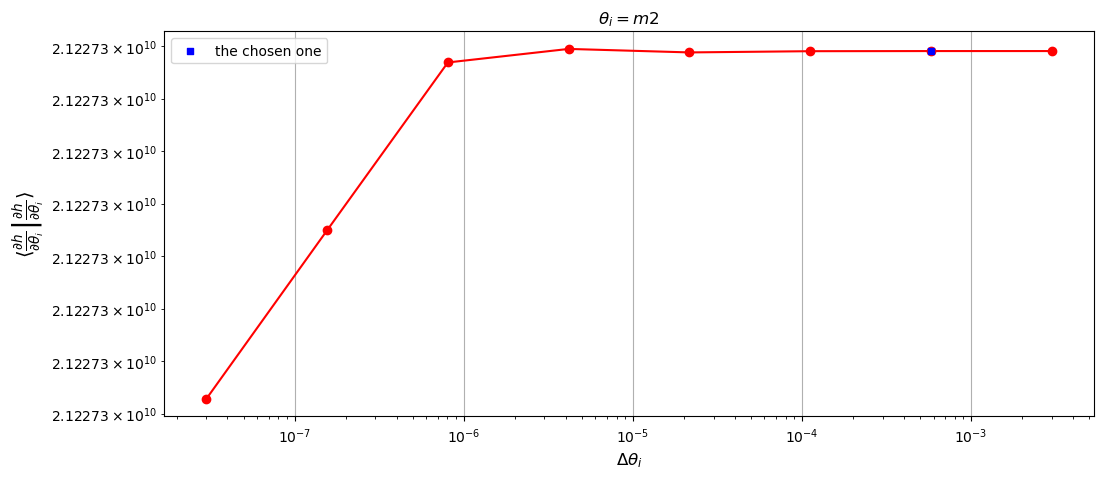

Gamma_ii for a: 23167882053073.094
Gamma_ii for a: 23167889371352.16
Gamma_ii for a: 23167871207049.7
Gamma_ii for a: 23167848060874.188
Gamma_ii for a: 23166655352788.316
Gamma_ii for a: 23166738778375.04
Gamma_ii for a: 23220136117295.93
Gamma_ii for a: 23303158479100.51
[3.158802663938622e-07, 7.840298445465428e-07, 9.99064541985147e-07, 5.1483827410914565e-05, 3.6010932535972545e-06, 0.0022996135186785865, 0.003562708543523867]
0


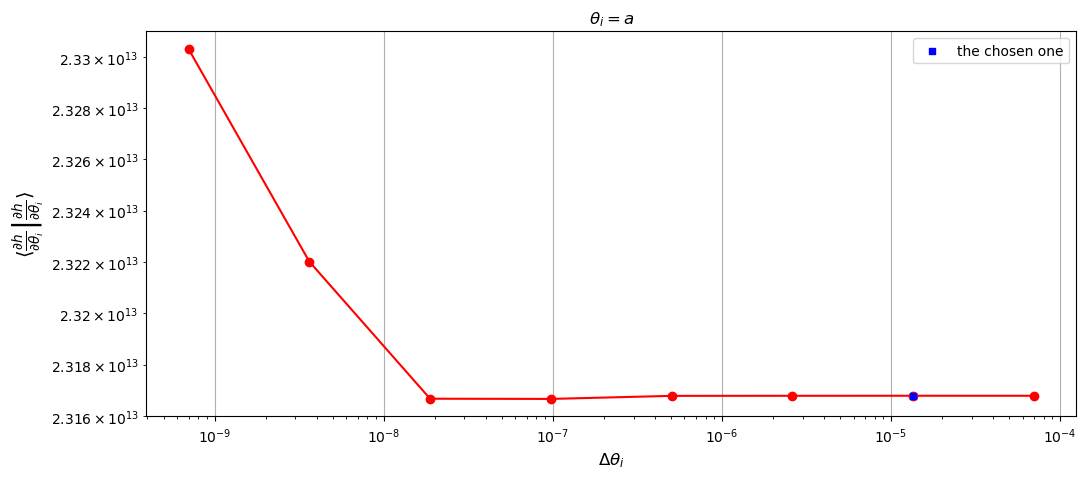

Gamma_ii for p0: 28486664707204.785
Gamma_ii for p0: 28486664571205.395
Gamma_ii for p0: 28486665476399.133
Gamma_ii for p0: 28486677884669.973
Gamma_ii for p0: 28486668891134.305
Gamma_ii for p0: 28486796307117.797
Gamma_ii for p0: 28486561108887.14
Gamma_ii for p0: 28479257143610.965
[4.774142310871647e-09, 3.1776051115255746e-08, 4.355815335884156e-07, 3.157103311144864e-07, 4.472808458996526e-06, 8.25646274947781e-06, 0.00025646614444135363]
0


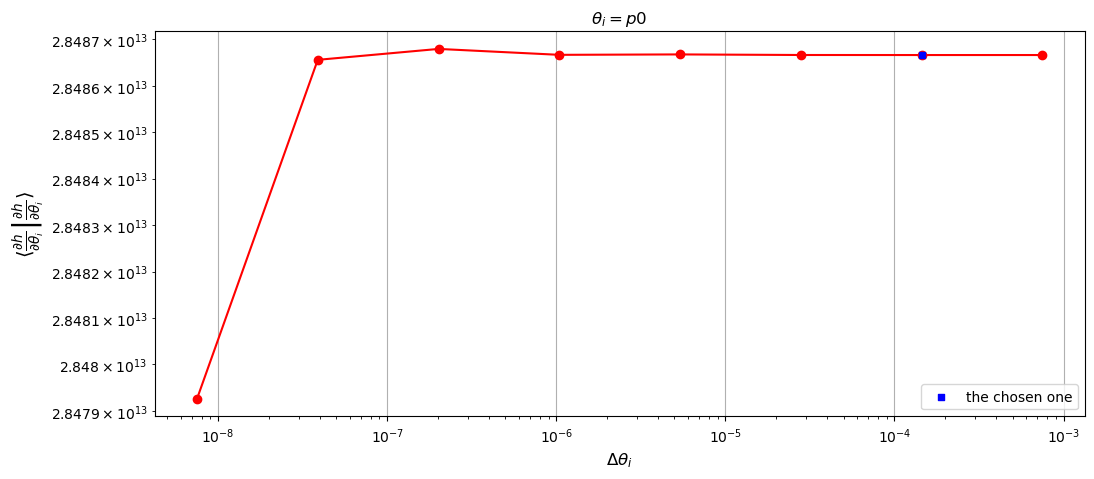

Gamma_ii for e0: 172687134259449.22
Gamma_ii for e0: 172687138288579.03
Gamma_ii for e0: 172687141139206.44
Gamma_ii for e0: 172687166662163.34
Gamma_ii for e0: 172684739885720.5
Gamma_ii for e0: 172699414658532.9
Gamma_ii for e0: 172555707601094.12
Gamma_ii for e0: 172762405421732.94
[2.333196237097221e-08, 1.6507467709781902e-08, 1.477988052012102e-07, 1.4053218856800808e-05, 8.497291575319872e-05, 0.0008328154393536273, 0.0011964282398953597]
1


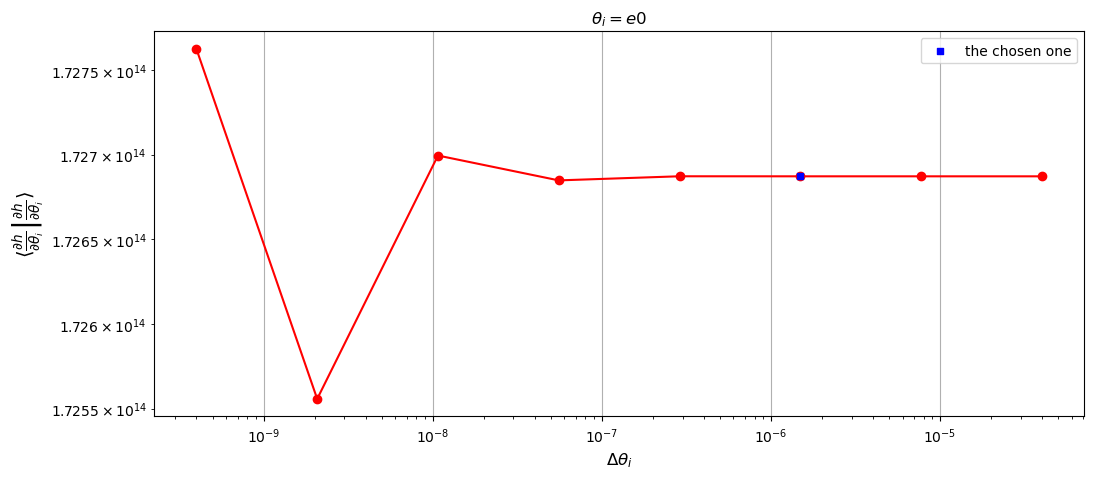

Gamma_ii for qS: 38367.03760832276
Gamma_ii for qS: 38367.04016171832
Gamma_ii for qS: 38367.04016527559
Gamma_ii for qS: 38367.04016528031
Gamma_ii for qS: 38367.040165278995
Gamma_ii for qS: 38367.040165279665
Gamma_ii for qS: 38367.040165376275
Gamma_ii for qS: 38367.040165755105
[6.655179947141703e-08, 9.271673274648665e-11, 1.2307690328111978e-13, 3.4324991515999147e-14, 1.7446957013656722e-14, 2.5180510350733764e-12, 9.87383982458472e-12]
4


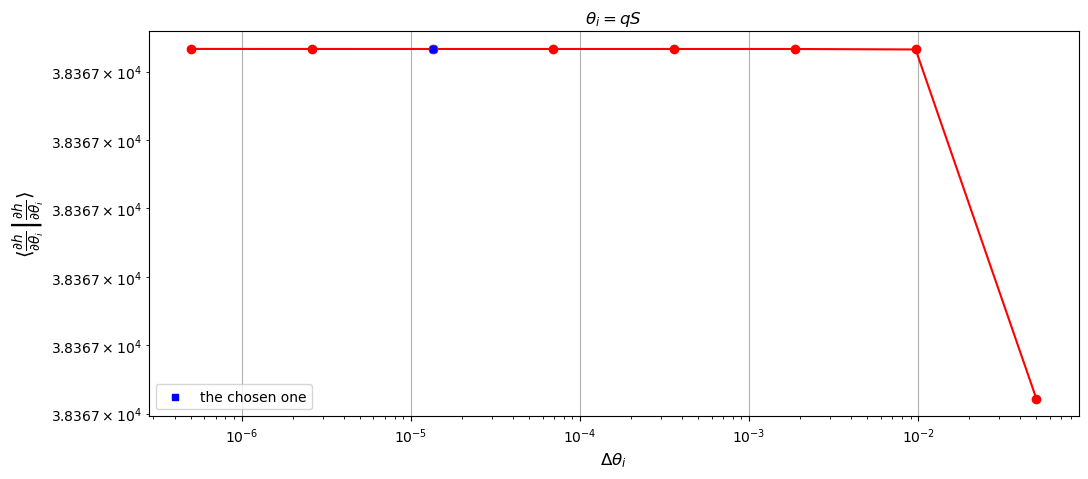

stable deltas: {'m1': 0.13894954943731375, 'm2': 0.0005792093186649751, 'a': 1.351488410218275e-05, 'p0': 0.0001448023296662437, 'e0': 1.4910374881259754e-06, 'dist': 0.0, 'qS': 1.3413478976398634e-05, 'Phi_phi0': 0.0, 'Phi_r0': 0.0}
Time taken to compute stable deltas is 401.560861825943 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 58.88339924812317 seconds


In [5]:
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
# dropping phiS
param_names = ['m1','m2','a','p0','e0','dist','qS','Phi_phi0','Phi_r0']
der_order = 4
Ndelta = 8
stability_plot = True
# using default delta range first by SEF
Fisher = sef(*pars_list, param_names = param_names, 
             T = T, dt = dt, 
             der_order = der_order, 
             Ndelta = Ndelta, 
             stability_plot = stability_plot,
            #  delta_range = delta_range,
            live_dangerously = False)

In [6]:
np.linalg.eigvals(Fisher)

array([2.16163024e+14, 8.05812363e+12, 1.41763583e+11, 1.08431480e+07,
       4.63932175e+04, 9.91541974e+03, 3.15055793e-06, 2.25288139e+03,
       7.88837046e+02])

In [10]:
# CHAIN RULE FOR FISHER
J_mx = np.eye(9)
J_mx[0, 0] = m1 * np.log(10) 
J_mx[1, 1] = m2 * np.log(10) 
J_mx[6, 6] = -1/np.sin(qS)

Fisher_scaled = J_mx.T @ Fisher @ J_mx

(<Figure size 2000x2000 with 45 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <

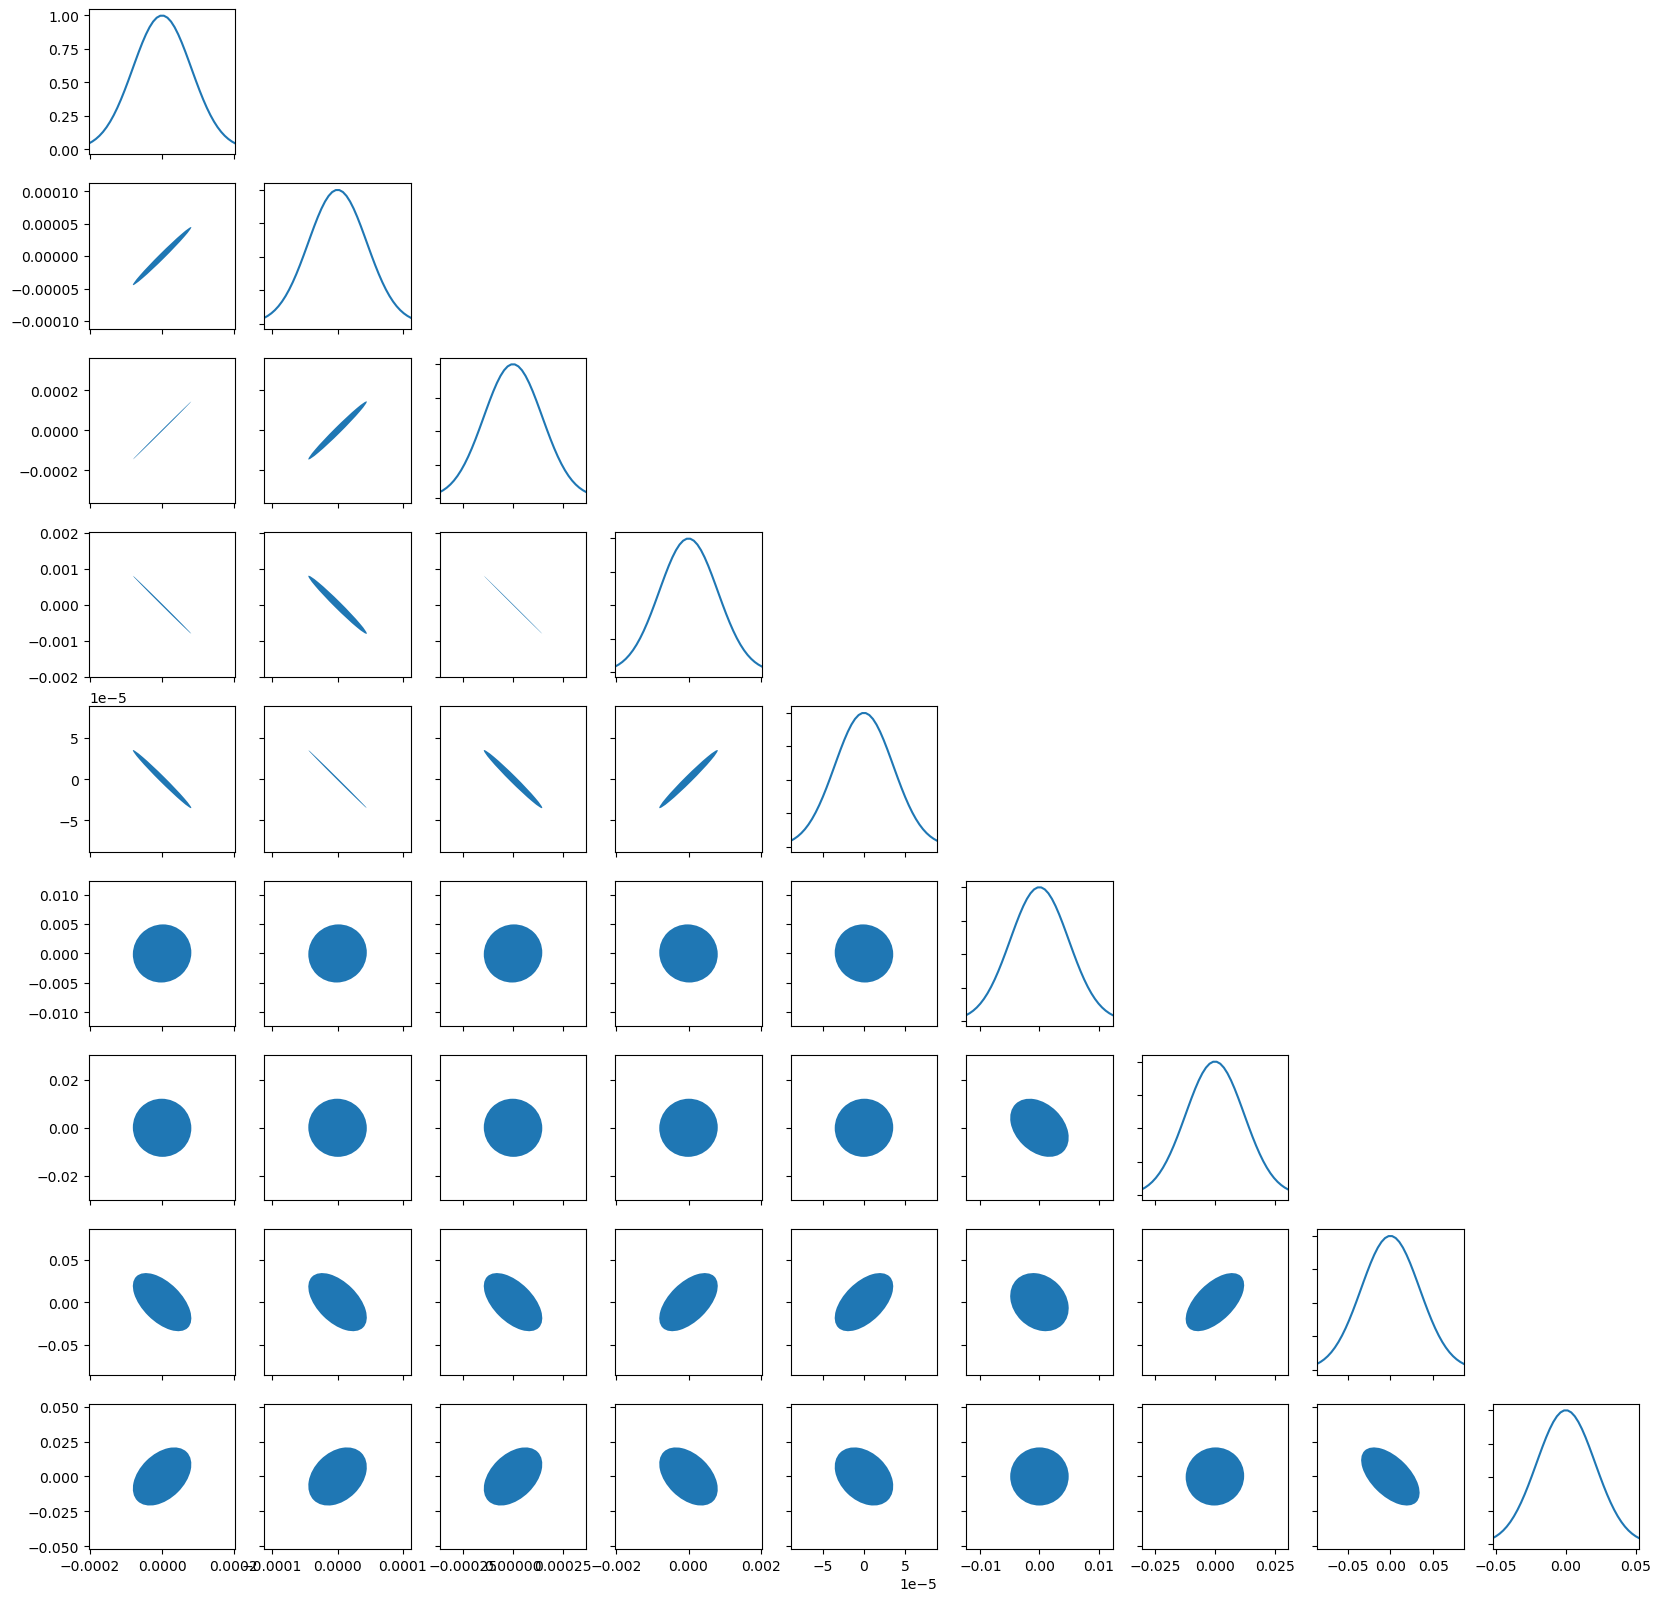

In [11]:
from stableemrifisher.plot import CovEllipsePlot

CovEllipsePlot(np.linalg.inv(Fisher_scaled))

In [12]:
cov = np.linalg.inv(Fisher_scaled)
cov

array([[ 6.61695461e-09,  3.60293877e-09,  1.18258743e-08,
        -6.57747692e-08, -2.84232042e-09,  1.32910908e-08,
        -1.42673387e-08, -1.53895195e-06,  7.05159242e-07],
       [ 3.60293877e-09,  2.00117289e-09,  6.42177132e-09,
        -3.56535330e-08, -1.57857275e-09,  7.33267569e-09,
        -7.86376590e-09, -8.03350465e-07,  3.03049848e-07],
       [ 1.18258743e-08,  6.42177132e-09,  2.11473707e-08,
        -1.17632655e-07, -5.06384250e-09,  2.37996935e-08,
        -2.60939077e-08, -2.73301492e-06,  1.27654850e-06],
       [-6.57747692e-08, -3.56535330e-08, -1.17632655e-07,
         6.54497647e-07,  2.81224121e-08, -1.31869815e-07,
         1.42464220e-07,  1.53756497e-05, -7.30994152e-06],
       [-2.84232042e-09, -1.57857275e-09, -5.06384250e-09,
         2.81224121e-08,  1.24669214e-09, -5.73969733e-09,
         5.88092926e-09,  6.53344661e-07, -2.46273455e-07],
       [ 1.32910908e-08,  7.33267569e-09,  2.37996935e-08,
        -1.31869815e-07, -5.73969733e-09,  2.447846

In [13]:
sigmas = []
for i in range(9):
    sigma_i = np.sqrt(cov[i, i])
    sigmas.append(sigma_i)

In [14]:
param_range = []
param_true = [np.log10(m1), np.log10(m2), a, p0, e0, dist, np.cos(qS), Phi_phi0, Phi_r0]
for i in range(9):
    param_min = param_true[i] - 3*sigmas[i]
    param_max = param_true[i] + 3*sigmas[i]
    param_range.append([param_min, param_max])

In [15]:
param_range

[[5.9997559660034545, 6.0002440339965455],
 [1.4769870513067693, 1.4772554581325554],
 [0.6995637359323849, 0.700436264067615],
 [7.497572969135001, 7.502427030864999],
 [0.39989407441651065, 0.4001059255834894],
 [0.48515728649322165, 0.5148427135067783],
 [0.8410565746295281, 0.9141085491512174],
 [0.29766594651745004, 0.50233405348255],
 [0.43749426805155983, 0.5625057319484402]]

In [16]:
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/sampling_test')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/sampling_test')

import pickle
with open('cov_matrix_reduced.pkl', 'wb') as f:
    pickle.dump(cov, f)